# Feature Multicollinearity Analysis

This notebook explores the correlation structure of our features to:
1. Identify highly correlated feature groups
2. Quantify multicollinearity using VIF
3. Use hierarchical clustering to find natural feature groupings
4. Recommend representative features for each group

Goal: Create a reduced feature set for better SHAP interpretability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Load Training Data

In [2]:
# Load the processed training data
batters = pd.read_csv('../data/processed/batters_processed.csv')
pitchers = pd.read_csv('../data/processed/pitchers_processed.csv')

print(f"Batters: {batters.shape}")
print(f"Pitchers: {pitchers.shape}")

Batters: (3663, 90)
Pitchers: (4104, 193)


In [3]:
# Identify feature columns (exclude IDs, names, target, etc.)
exclude_cols = ['IDfg', 'Name', 'Team', 'Season', 'Age', 'G', 'PA', 'AB', 'IP',
                'Fpoints_PA', 'Fpoints_IP', 'Fpoints', 'target', 'Position', 'Role']

batter_features = [c for c in batters.columns if c not in exclude_cols 
                   and not c.startswith('Unnamed')
                   and batters[c].dtype in ['float64', 'int64']]

pitcher_features = [c for c in pitchers.columns if c not in exclude_cols
                    and not c.startswith('Unnamed')
                    and pitchers[c].dtype in ['float64', 'int64']]

print(f"Batter features: {len(batter_features)}")
print(f"Pitcher features: {len(pitcher_features)}")

Batter features: 81
Pitcher features: 185


---
# Part 1: Batter Feature Analysis
---

## 2. Correlation Matrix

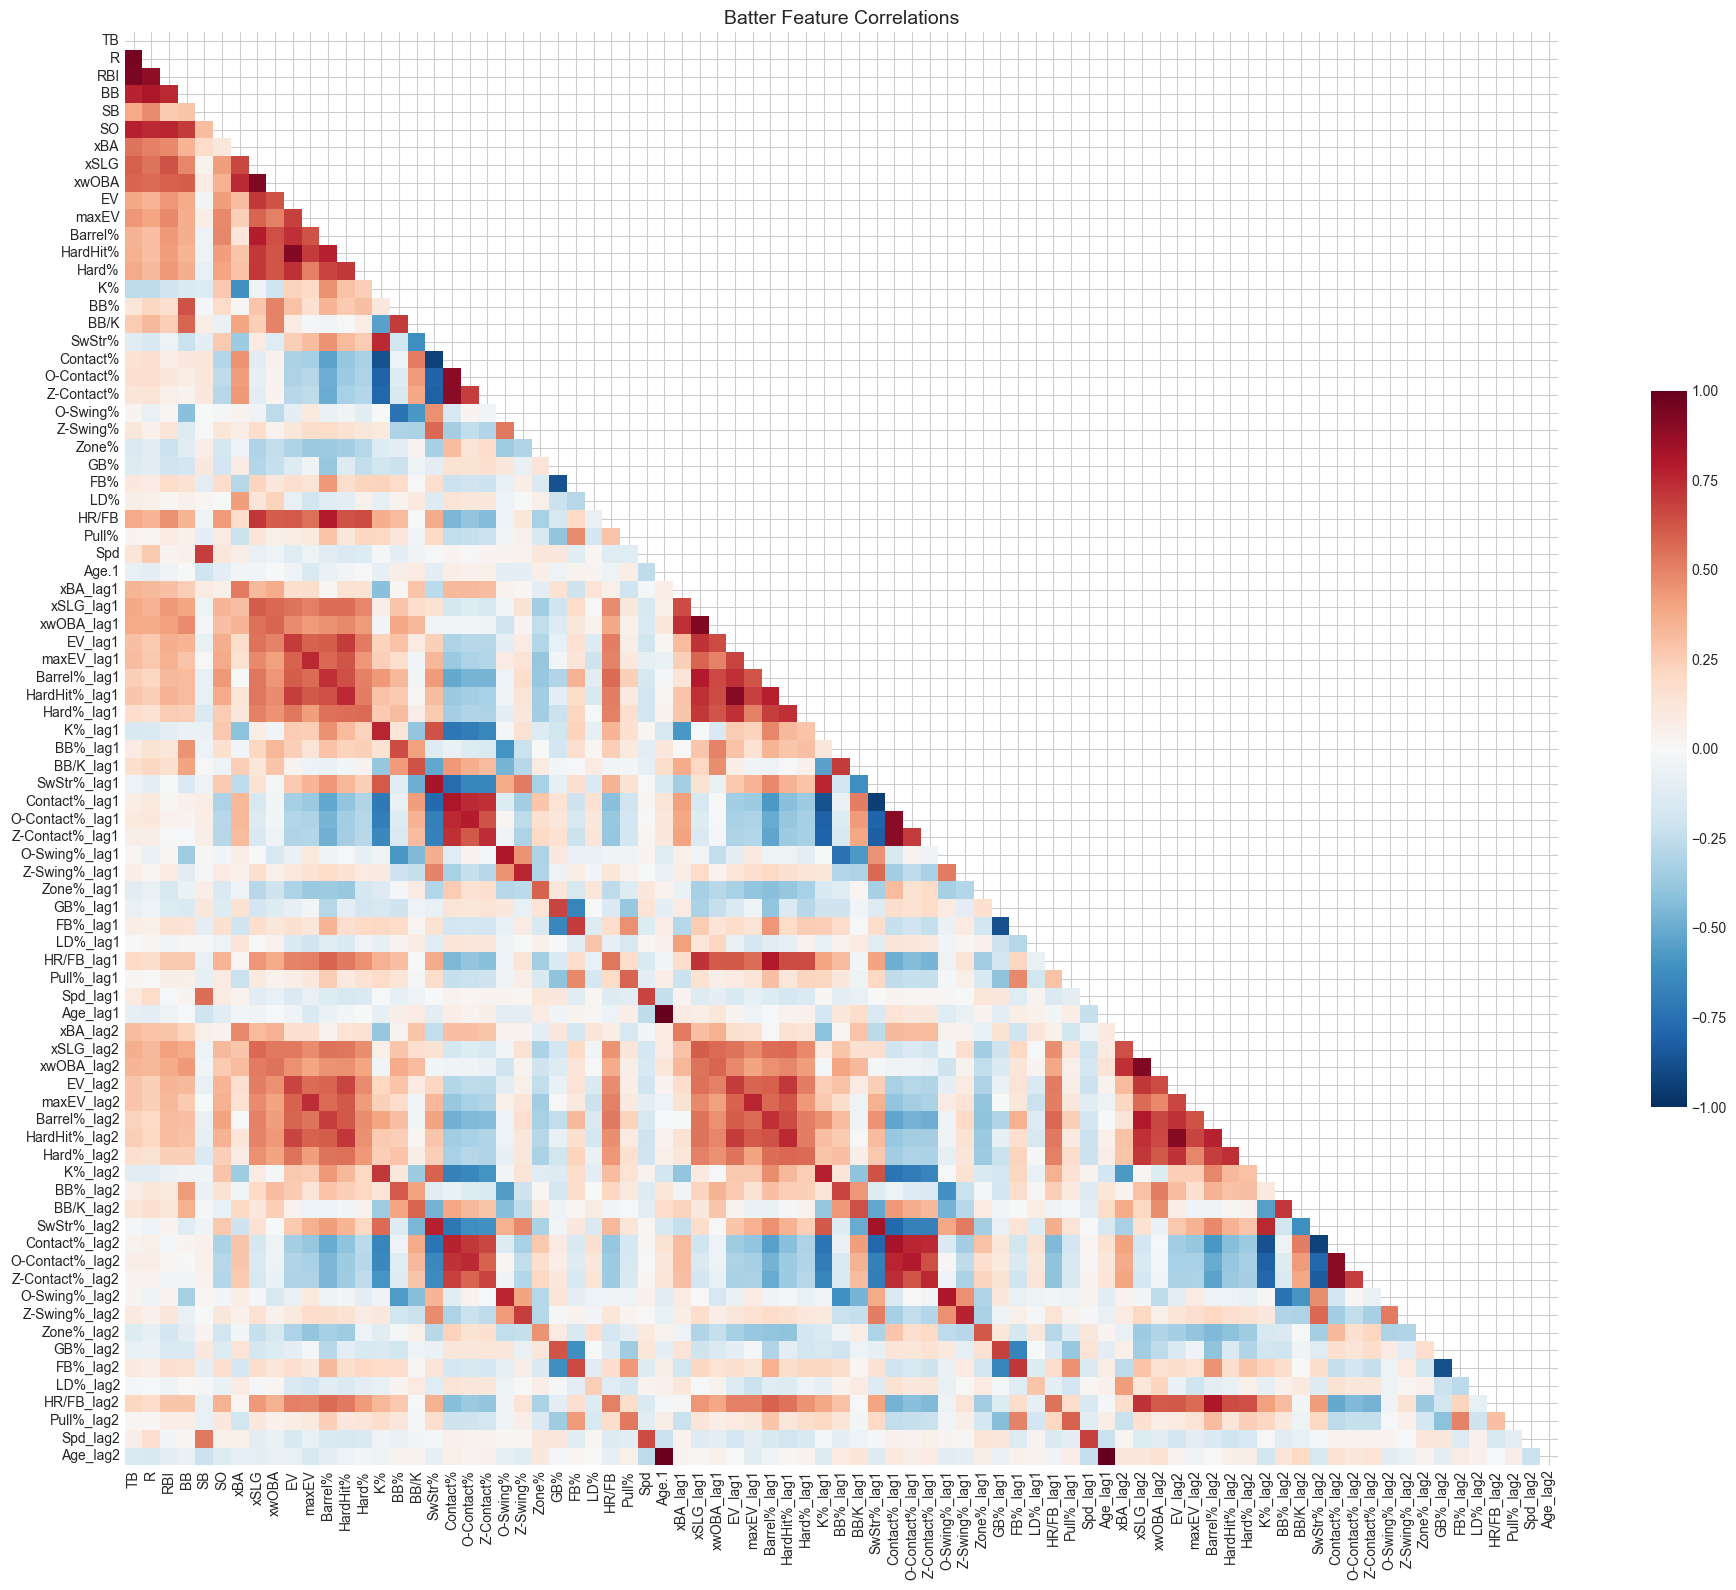

In [4]:
# Compute correlation matrix for batters
batter_corr = batters[batter_features].corr()

# Plot full correlation heatmap
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(batter_corr, dtype=bool))
sns.heatmap(batter_corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={'shrink': 0.5})
ax.set_title('Batter Feature Correlations', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Find highly correlated pairs (|r| > 0.8)
high_corr_pairs = []
for i in range(len(batter_corr.columns)):
    for j in range(i+1, len(batter_corr.columns)):
        if abs(batter_corr.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': batter_corr.columns[i],
                'Feature 2': batter_corr.columns[j],
                'Correlation': batter_corr.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(f"Highly correlated pairs (|r| > 0.8): {len(high_corr_df)}")
print("\nTop 20 correlated pairs:")
high_corr_df.head(20)

Highly correlated pairs (|r| > 0.8): 44

Top 20 correlated pairs:


,Feature 1,Feature 2,Correlation
32,Age_lag1,Age_lag2,0.995192
16,Age.1,Age_lag1,0.994971
17,Age.1,Age_lag2,0.990494
0,TB,R,0.956968
1,TB,RBI,0.949108
23,SwStr%_lag1,Contact%_lag1,-0.938253
39,SwStr%_lag2,Contact%_lag2,-0.937440
8,SwStr%,Contact%,-0.935510
4,xSLG,xwOBA,0.930552
18,xSLG_lag1,xwOBA_lag1,0.928748


## 3. Hierarchical Clustering of Features

Use correlation-based distance to cluster similar features together.

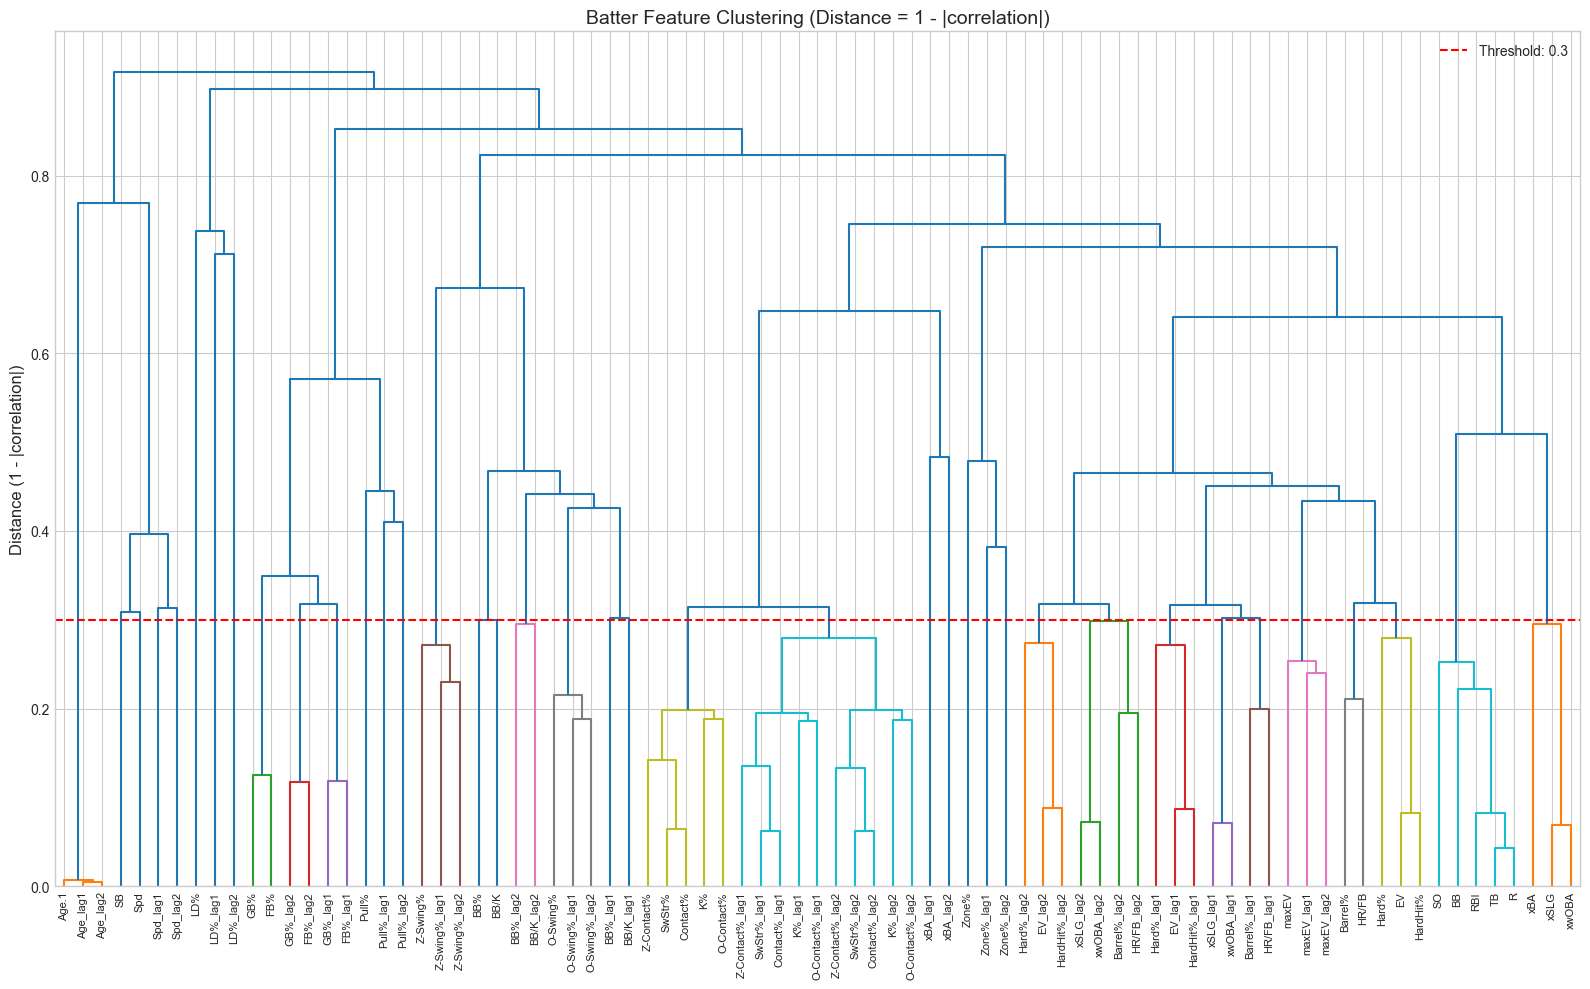

In [6]:
def cluster_features(corr_matrix, title="Feature Clustering", threshold=0.5):
    """
    Perform hierarchical clustering on features based on correlation.
    Distance = 1 - |correlation|
    """
    # Convert correlation to distance
    dissimilarity = 1 - np.abs(corr_matrix)
    np.fill_diagonal(dissimilarity.values, 0)
    
    # Hierarchical clustering
    linkage = hierarchy.linkage(squareform(dissimilarity), method='average')
    
    # Plot dendrogram
    fig, ax = plt.subplots(figsize=(16, 10))
    dendro = hierarchy.dendrogram(
        linkage,
        labels=corr_matrix.columns,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=threshold,
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Distance (1 - |correlation|)', fontsize=12)
    ax.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold: {threshold}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Get cluster assignments
    clusters = hierarchy.fcluster(linkage, threshold, criterion='distance')
    cluster_df = pd.DataFrame({
        'Feature': corr_matrix.columns,
        'Cluster': clusters
    }).sort_values('Cluster')
    
    return cluster_df, linkage

batter_clusters, batter_linkage = cluster_features(
    batter_corr, 
    title="Batter Feature Clustering (Distance = 1 - |correlation|)",
    threshold=0.3  # Features with |r| > 0.7 will cluster together
)

In [7]:
# Show clusters
print("Batter Feature Clusters:")
print("=" * 60)
for cluster_id in sorted(batter_clusters['Cluster'].unique()):
    features = batter_clusters[batter_clusters['Cluster'] == cluster_id]['Feature'].tolist()
    print(f"\nCluster {cluster_id} ({len(features)} features):")
    for f in features:
        print(f"  - {f}")

Batter Feature Clusters:

Cluster 1 (3 features):
  - Age_lag2
  - Age.1
  - Age_lag1

Cluster 2 (1 features):
  - SB

Cluster 3 (1 features):
  - Spd

Cluster 4 (1 features):
  - Spd_lag1

Cluster 5 (1 features):
  - Spd_lag2

Cluster 6 (1 features):
  - LD%_lag1

Cluster 7 (1 features):
  - LD%_lag2

Cluster 8 (1 features):
  - LD%

Cluster 9 (2 features):
  - FB%
  - GB%

Cluster 10 (2 features):
  - FB%_lag2
  - GB%_lag2

Cluster 11 (2 features):
  - GB%_lag1
  - FB%_lag1

Cluster 12 (1 features):
  - Pull%_lag1

Cluster 13 (1 features):
  - Pull%_lag2

Cluster 14 (1 features):
  - Pull%

Cluster 15 (3 features):
  - Z-Swing%_lag1
  - Z-Swing%
  - Z-Swing%_lag2

Cluster 16 (1 features):
  - BB%

Cluster 17 (1 features):
  - BB/K

Cluster 18 (2 features):
  - BB%_lag2
  - BB/K_lag2

Cluster 19 (3 features):
  - O-Swing%_lag1
  - O-Swing%
  - O-Swing%_lag2

Cluster 20 (1 features):
  - BB%_lag1

Cluster 21 (1 features):
  - BB/K_lag1

Cluster 22 (5 features):
  - Contact%
  - K%
  - 

## 4. Variance Inflation Factor (VIF)

VIF measures how much the variance of a regression coefficient is inflated due to multicollinearity.
- VIF = 1: No correlation
- VIF = 1-5: Moderate correlation
- VIF > 5: High correlation (problematic)
- VIF > 10: Severe multicollinearity

In [8]:
def calculate_vif(df, features):
    """
    Calculate VIF for each feature.
    """
    # Prepare data - drop NaN and scale
    X = df[features].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Calculate VIF
    vif_data = []
    for i, feature in enumerate(features):
        try:
            vif = variance_inflation_factor(X_scaled, i)
            vif_data.append({'Feature': feature, 'VIF': vif})
        except:
            vif_data.append({'Feature': feature, 'VIF': np.nan})
    
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Calculate VIF for batters (use subset to avoid computation issues)
batter_vif = calculate_vif(batters, batter_features)
print("Batter VIF Analysis:")
print(f"Features with VIF > 10 (severe multicollinearity): {len(batter_vif[batter_vif['VIF'] > 10])}")
print(f"Features with VIF > 5 (high multicollinearity): {len(batter_vif[batter_vif['VIF'] > 5])}")
print("\nTop 20 highest VIF:")
batter_vif.head(20)

Batter VIF Analysis:
Features with VIF > 10 (severe multicollinearity): 59
Features with VIF > 5 (high multicollinearity): 66

Top 20 highest VIF:


,Feature,VIF
25,FB%,21373.646288
50,FB%_lag1,21014.459347
75,FB%_lag2,20842.381101
24,GB%,20629.755104
74,GB%_lag2,20216.553949
49,GB%_lag1,20077.215375
26,LD%,5092.187649
51,LD%_lag1,4906.053914
76,LD%_lag2,4815.016259
43,Contact%_lag1,655.142951


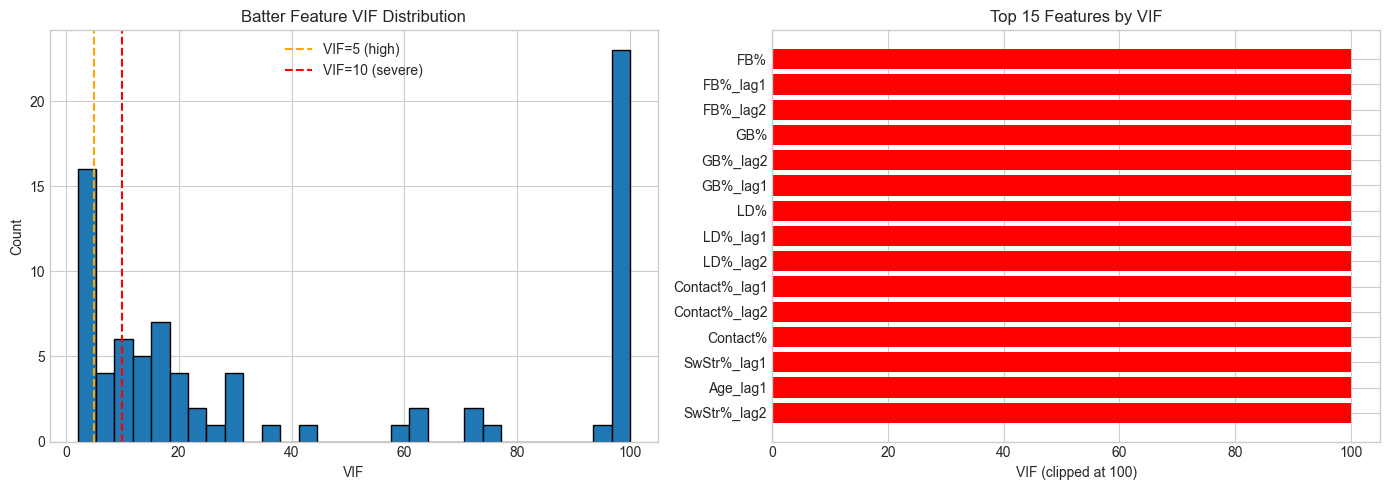

In [9]:
# Plot VIF distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(batter_vif['VIF'].dropna().clip(upper=100), bins=30, edgecolor='black')
axes[0].axvline(x=5, color='orange', linestyle='--', label='VIF=5 (high)')
axes[0].axvline(x=10, color='red', linestyle='--', label='VIF=10 (severe)')
axes[0].set_xlabel('VIF')
axes[0].set_ylabel('Count')
axes[0].set_title('Batter Feature VIF Distribution')
axes[0].legend()

# Top VIF bar chart
top_vif = batter_vif.head(15).copy()
top_vif['VIF_clipped'] = top_vif['VIF'].clip(upper=100)
colors = ['red' if v > 10 else 'orange' if v > 5 else 'green' for v in top_vif['VIF']]
axes[1].barh(top_vif['Feature'], top_vif['VIF_clipped'], color=colors)
axes[1].set_xlabel('VIF (clipped at 100)')
axes[1].set_title('Top 15 Features by VIF')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Focused Correlation Analysis by Concept

Let's look at specific feature groups to understand redundancy.

In [10]:
def plot_group_correlation(df, features, title):
    """
    Plot correlation heatmap for a specific group of features.
    """
    available = [f for f in features if f in df.columns]
    if len(available) < 2:
        print(f"Not enough features available for {title}")
        return None
    
    corr = df[available].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, fmt='.2f', ax=ax, square=True)
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return corr

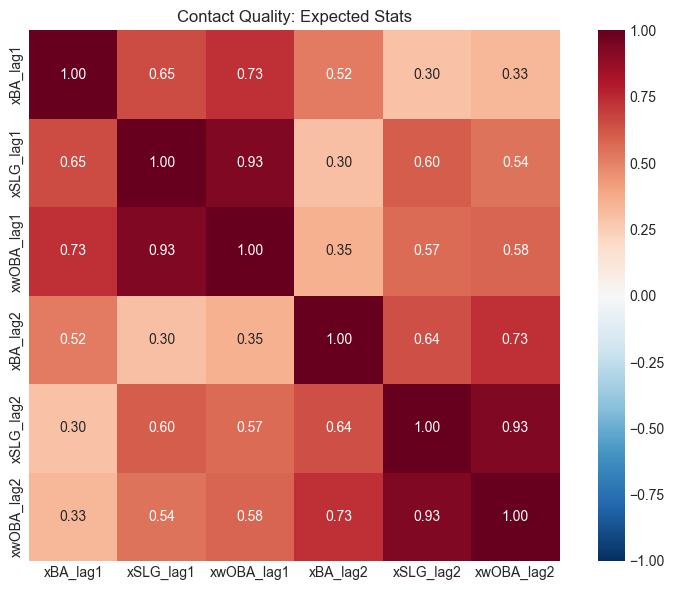

,xBA_lag1,xSLG_lag1,xwOBA_lag1,xBA_lag2,xSLG_lag2,xwOBA_lag2
xBA_lag1,1.000000,0.649200,0.730812,0.517178,0.295058,0.329403
xSLG_lag1,0.649200,1.000000,0.928748,0.298036,0.603218,0.540364
xwOBA_lag1,0.730812,0.928748,1.000000,0.353299,0.568922,0.582710
xBA_lag2,0.517178,0.298036,0.353299,1.000000,0.643907,0.726719
xSLG_lag2,0.295058,0.603218,0.568922,0.643907,1.000000,0.927835
xwOBA_lag2,0.329403,0.540364,0.582710,0.726719,0.927835,1.000000


In [11]:
# Contact Quality / Expected Stats
contact_features = ['xBA_lag1', 'xSLG_lag1', 'xwOBA_lag1', 'xBA_lag2', 'xSLG_lag2', 'xwOBA_lag2']
plot_group_correlation(batters, contact_features, 'Contact Quality: Expected Stats')

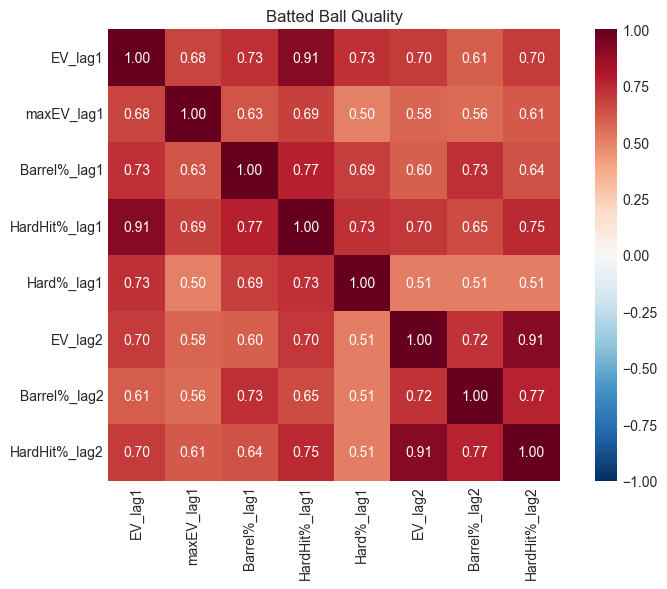

,EV_lag1,maxEV_lag1,Barrel%_lag1,HardHit%_lag1,Hard%_lag1,EV_lag2,Barrel%_lag2,HardHit%_lag2
EV_lag1,1.000000,0.676243,0.727807,0.912898,0.730273,0.699416,0.606741,0.695475
maxEV_lag1,0.676243,1.000000,0.631642,0.685863,0.500378,0.580573,0.564655,0.610180
Barrel%_lag1,0.727807,0.631642,1.000000,0.774548,0.691508,0.595121,0.733222,0.640425
HardHit%_lag1,0.912898,0.685863,0.774548,1.000000,0.727578,0.704662,0.649865,0.750385
Hard%_lag1,0.730273,0.500378,0.691508,0.727578,1.000000,0.514997,0.507821,0.511821
EV_lag2,0.699416,0.580573,0.595121,0.704662,0.514997,1.000000,0.723028,0.912148
Barrel%_lag2,0.606741,0.564655,0.733222,0.649865,0.507821,0.723028,1.000000,0.770837
HardHit%_lag2,0.695475,0.610180,0.640425,0.750385,0.511821,0.912148,0.770837,1.000000


In [12]:
# Batted Ball Quality
batted_ball = ['EV_lag1', 'maxEV_lag1', 'Barrel%_lag1', 'HardHit%_lag1', 'Hard%_lag1',
               'EV_lag2', 'Barrel%_lag2', 'HardHit%_lag2']
plot_group_correlation(batters, batted_ball, 'Batted Ball Quality')

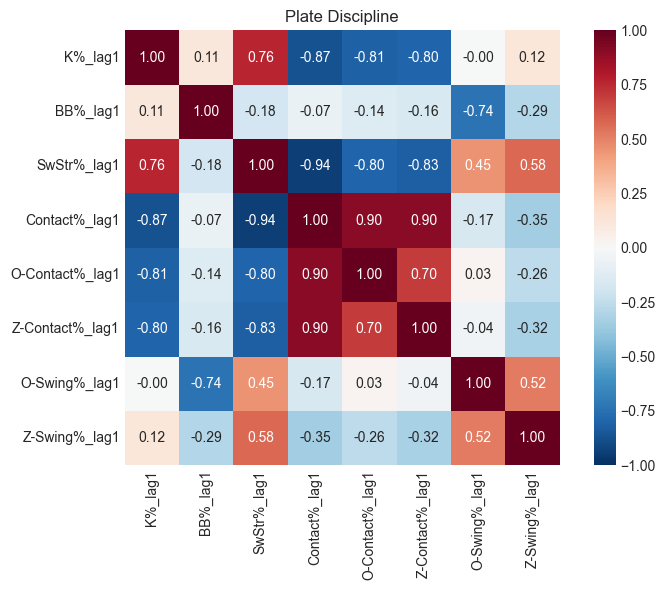

,K%_lag1,BB%_lag1,SwStr%_lag1,Contact%_lag1,O-Contact%_lag1,Z-Contact%_lag1,O-Swing%_lag1,Z-Swing%_lag1
K%_lag1,1.000000,0.114130,0.758938,-0.870894,-0.813885,-0.798255,-0.002796,0.117533
BB%_lag1,0.114130,1.000000,-0.181775,-0.066662,-0.139132,-0.157248,-0.735318,-0.293593
SwStr%_lag1,0.758938,-0.181775,1.000000,-0.938253,-0.800894,-0.827245,0.451235,0.576191
Contact%_lag1,-0.870894,-0.066662,-0.938253,1.000000,0.902522,0.902857,-0.166834,-0.351351
O-Contact%_lag1,-0.813885,-0.139132,-0.800894,0.902522,1.000000,0.696361,0.027514,-0.258672
Z-Contact%_lag1,-0.798255,-0.157248,-0.827245,0.902857,0.696361,1.000000,-0.043529,-0.322947
O-Swing%_lag1,-0.002796,-0.735318,0.451235,-0.166834,0.027514,-0.043529,1.000000,0.520065
Z-Swing%_lag1,0.117533,-0.293593,0.576191,-0.351351,-0.258672,-0.322947,0.520065,1.000000


In [13]:
# Plate Discipline
discipline = ['K%_lag1', 'BB%_lag1', 'SwStr%_lag1', 'Contact%_lag1', 
              'O-Contact%_lag1', 'Z-Contact%_lag1', 'O-Swing%_lag1', 'Z-Swing%_lag1']
plot_group_correlation(batters, discipline, 'Plate Discipline')

In [14]:
# Lag1 vs Lag2 correlation for same metrics
lag_pairs = []
for col in batters.columns:
    if '_lag1' in col:
        lag2_col = col.replace('_lag1', '_lag2')
        if lag2_col in batters.columns:
            corr = batters[col].corr(batters[lag2_col])
            lag_pairs.append({'Metric': col.replace('_lag1', ''), 'Lag1-Lag2 Corr': corr})

lag_corr_df = pd.DataFrame(lag_pairs).sort_values('Lag1-Lag2 Corr', ascending=False)
print("Lag1 vs Lag2 Correlations (same metric):")
print(f"Mean correlation: {lag_corr_df['Lag1-Lag2 Corr'].mean():.3f}")
print(f"Min correlation: {lag_corr_df['Lag1-Lag2 Corr'].min():.3f}")
print("\nAll pairs:")
lag_corr_df

Lag1 vs Lag2 Correlations (same metric):
Mean correlation: 0.689
Min correlation: 0.288

All pairs:


,Metric,Lag1-Lag2 Corr
24,Age,0.995192
11,SwStr%,0.840673
12,Contact%,0.831967
15,O-Swing%,0.811187
13,O-Contact%,0.792078
8,K%,0.774682
16,Z-Swing%,0.770044
4,maxEV,0.759621
14,Z-Contact%,0.750550
6,HardHit%,0.750385


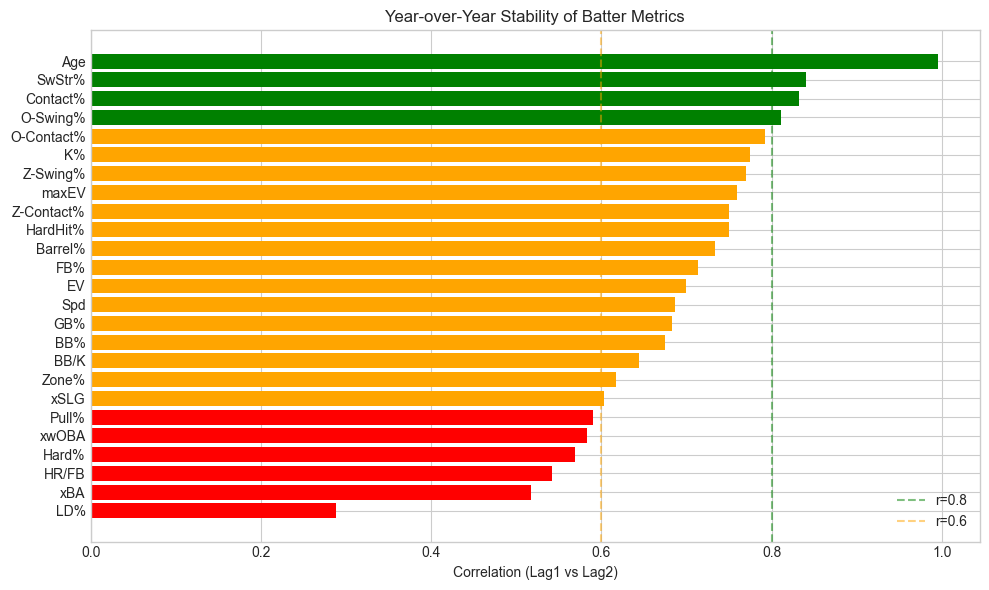


Interpretation:
- High correlation (green): Metric is stable year-to-year, lag2 adds little new info
- Low correlation (red): Metric varies year-to-year, lag2 may add value


In [15]:
# Visualize lag correlations
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0.8 else 'orange' if c > 0.6 else 'red' for c in lag_corr_df['Lag1-Lag2 Corr']]
ax.barh(lag_corr_df['Metric'], lag_corr_df['Lag1-Lag2 Corr'], color=colors)
ax.axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='r=0.8')
ax.axvline(x=0.6, color='orange', linestyle='--', alpha=0.5, label='r=0.6')
ax.set_xlabel('Correlation (Lag1 vs Lag2)')
ax.set_title('Year-over-Year Stability of Batter Metrics')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High correlation (green): Metric is stable year-to-year, lag2 adds little new info")
print("- Low correlation (red): Metric varies year-to-year, lag2 may add value")

## 6. Selecting Representative Features

For each cluster, select the feature with:
1. Highest correlation with target (predictive power)
2. Lowest average correlation with other clusters (independence)

In [16]:
def select_representatives(df, features, clusters_df, target_col):
    """
    Select best representative from each cluster based on target correlation.
    """
    results = []
    
    for cluster_id in sorted(clusters_df['Cluster'].unique()):
        cluster_features = clusters_df[clusters_df['Cluster'] == cluster_id]['Feature'].tolist()
        
        # Calculate correlation with target for each feature
        target_corrs = {}
        for f in cluster_features:
            if f in df.columns and target_col in df.columns:
                corr = abs(df[f].corr(df[target_col]))
                target_corrs[f] = corr
        
        if target_corrs:
            best_feature = max(target_corrs, key=target_corrs.get)
            results.append({
                'Cluster': cluster_id,
                'Size': len(cluster_features),
                'Representative': best_feature,
                'Target_Corr': target_corrs[best_feature],
                'All_Features': ', '.join(cluster_features[:5]) + ('...' if len(cluster_features) > 5 else '')
            })
    
    return pd.DataFrame(results)

# Find target column
target_col = 'Fpoints_PA' if 'Fpoints_PA' in batters.columns else 'target'
print(f"Using target column: {target_col}")

batter_reps = select_representatives(batters, batter_features, batter_clusters, target_col)
print("\nRecommended Representative Features (Batters):")
batter_reps

Using target column: Fpoints_PA

Recommended Representative Features (Batters):


,Cluster,Size,Representative,Target_Corr,All_Features
0,1,3,Age_lag2,0.108803,"Age_lag2, Age.1, Age_lag1"
1,2,1,SB,0.268990,SB
2,3,1,Spd,0.158507,Spd
3,4,1,Spd_lag1,0.071584,Spd_lag1
4,5,1,Spd_lag2,0.075425,Spd_lag2
5,6,1,LD%_lag1,0.018913,LD%_lag1
6,7,1,LD%_lag2,0.011715,LD%_lag2
7,8,1,LD%,0.099796,LD%
8,9,2,GB%,0.157285,"FB%, GB%"
9,10,2,FB%_lag2,0.083351,"FB%_lag2, GB%_lag2"


---
# Part 2: Pitcher Feature Analysis
---

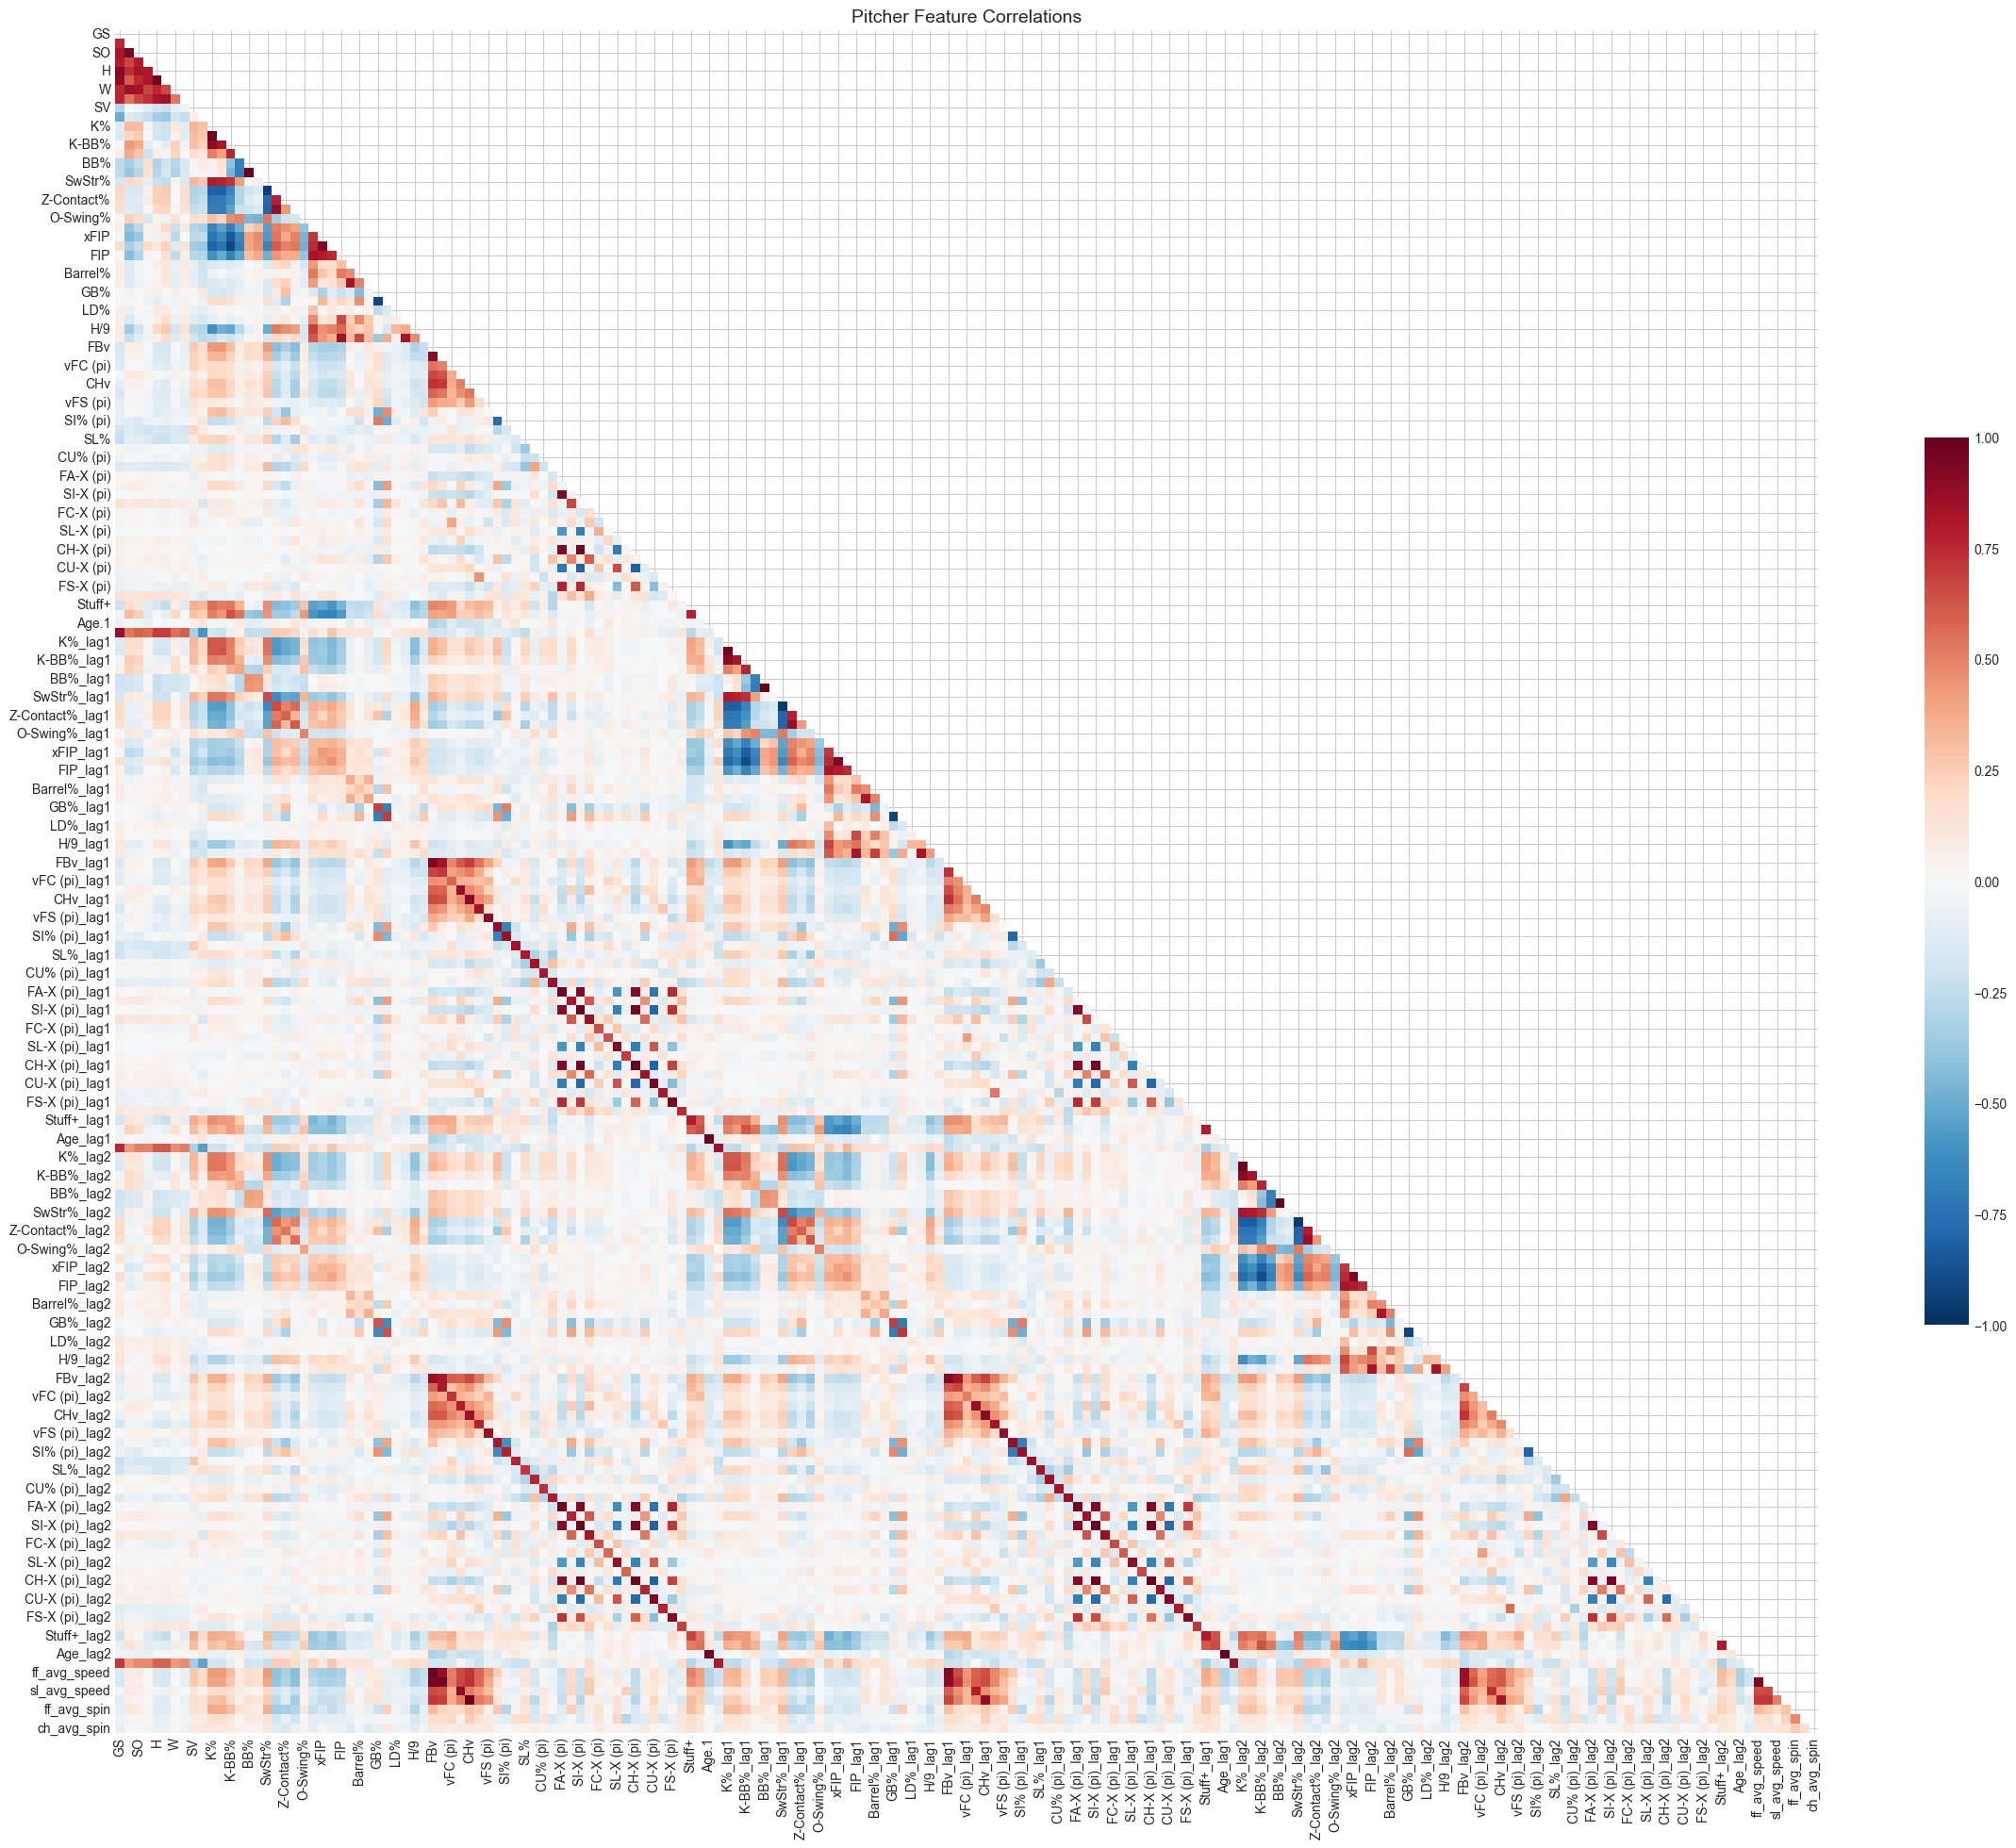

In [17]:
# Compute correlation matrix for pitchers
pitcher_corr = pitchers[pitcher_features].corr()

# Plot full correlation heatmap
fig, ax = plt.subplots(figsize=(24, 20))
mask = np.triu(np.ones_like(pitcher_corr, dtype=bool))
sns.heatmap(pitcher_corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={'shrink': 0.5})
ax.set_title('Pitcher Feature Correlations', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Find highly correlated pairs for pitchers
pitcher_high_corr = []
for i in range(len(pitcher_corr.columns)):
    for j in range(i+1, len(pitcher_corr.columns)):
        if abs(pitcher_corr.iloc[i, j]) > 0.8:
            pitcher_high_corr.append({
                'Feature 1': pitcher_corr.columns[i],
                'Feature 2': pitcher_corr.columns[j],
                'Correlation': pitcher_corr.iloc[i, j]
            })

pitcher_high_corr_df = pd.DataFrame(pitcher_high_corr).sort_values('Correlation', key=abs, ascending=False)
print(f"Highly correlated pitcher pairs (|r| > 0.8): {len(pitcher_high_corr_df)}")
print("\nTop 30 correlated pairs:")
pitcher_high_corr_df.head(30)

Highly correlated pitcher pairs (|r| > 0.8): 176

Top 30 correlated pairs:


,Feature 1,Feature 2,Correlation
157,BB%_lag2,BB/9_lag2,0.988926
104,BB%_lag1,BB/9_lag1,0.988329
147,Age_lag1,Age_lag2,0.987787
33,FBv,ff_avg_speed,0.987755
143,CH-X (pi)_lag1,CH-X (pi)_lag2,0.987660
21,BB%,BB/9,0.987274
80,CH-X (pi),CH-X (pi)_lag1,0.987099
92,Age.1,Age_lag1,0.986134
68,SI-X (pi),SI-X (pi)_lag1,0.985449
137,SI-X (pi)_lag1,SI-X (pi)_lag2,0.984148


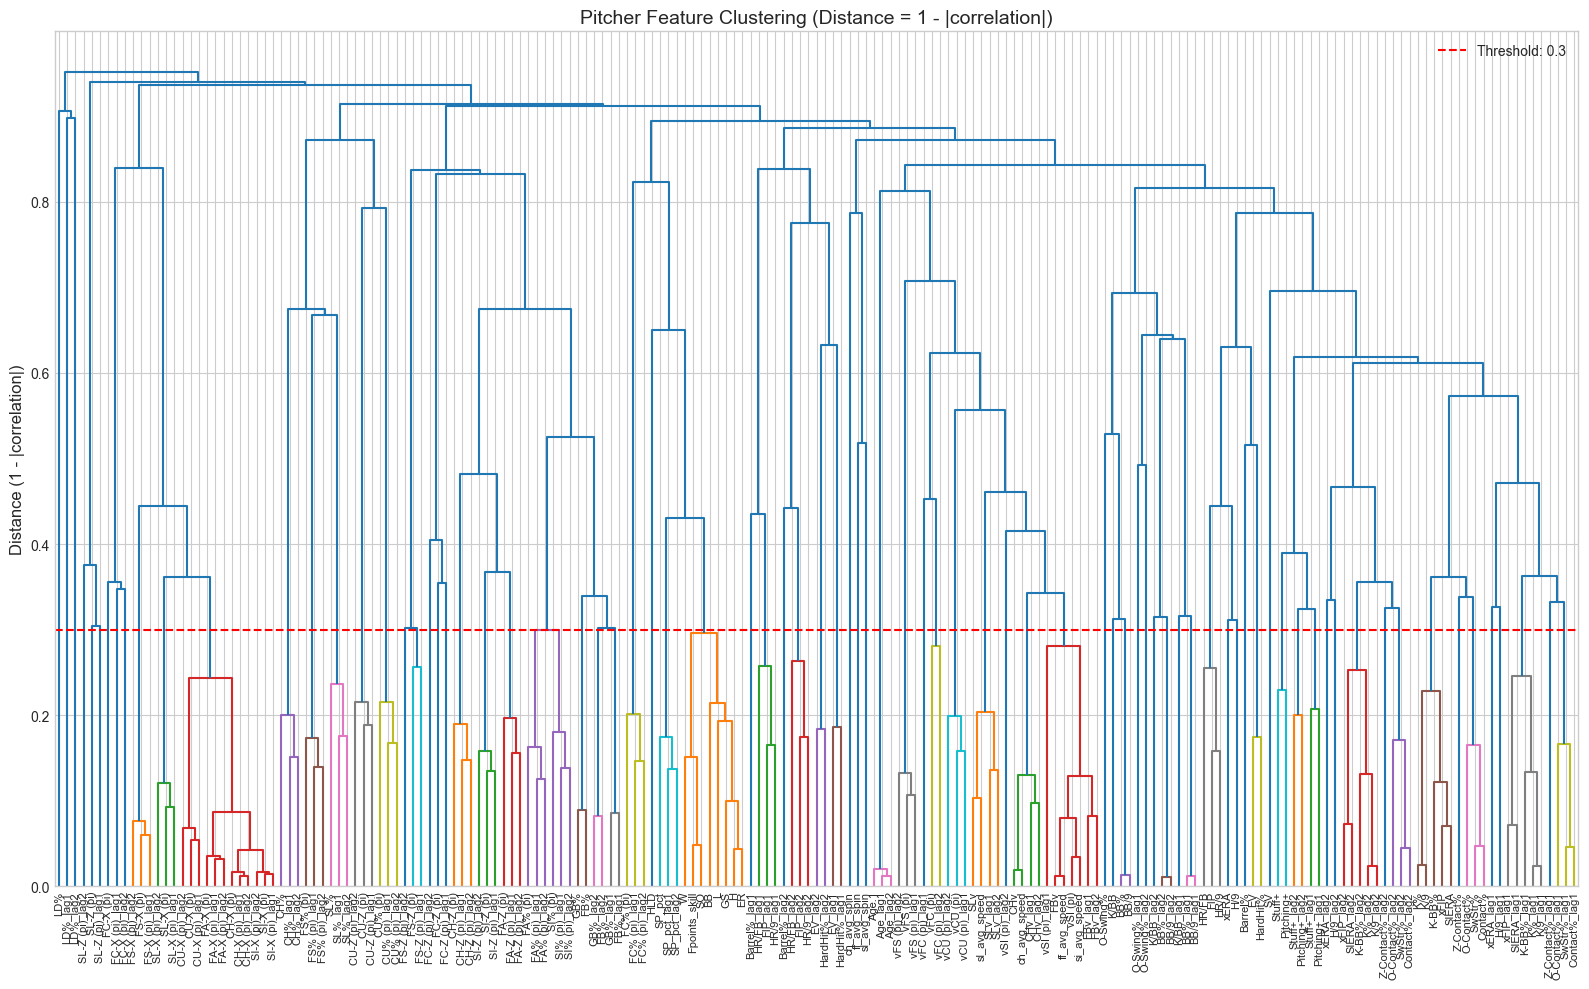

In [19]:
# Cluster pitcher features
pitcher_clusters, pitcher_linkage = cluster_features(
    pitcher_corr,
    title="Pitcher Feature Clustering (Distance = 1 - |correlation|)",
    threshold=0.3
)

In [20]:
# Show pitcher clusters
print("Pitcher Feature Clusters:")
print("=" * 60)
for cluster_id in sorted(pitcher_clusters['Cluster'].unique()):
    features = pitcher_clusters[pitcher_clusters['Cluster'] == cluster_id]['Feature'].tolist()
    print(f"\nCluster {cluster_id} ({len(features)} features):")
    for f in features[:10]:  # Show first 10
        print(f"  - {f}")
    if len(features) > 10:
        print(f"  ... and {len(features) - 10} more")

Pitcher Feature Clusters:

Cluster 1 (1 features):
  - LD%_lag1

Cluster 2 (1 features):
  - LD%_lag2

Cluster 3 (1 features):
  - LD%

Cluster 4 (1 features):
  - SL-Z (pi)

Cluster 5 (1 features):
  - SL-Z (pi)_lag1

Cluster 6 (1 features):
  - SL-Z (pi)_lag2

Cluster 7 (1 features):
  - FC-X (pi)_lag1

Cluster 8 (1 features):
  - FC-X (pi)_lag2

Cluster 9 (1 features):
  - FC-X (pi)

Cluster 10 (3 features):
  - FS-X (pi)
  - FS-X (pi)_lag1
  - FS-X (pi)_lag2

Cluster 11 (3 features):
  - SL-X (pi)
  - SL-X (pi)_lag2
  - SL-X (pi)_lag1

Cluster 12 (12 features):
  - FA-X (pi)_lag2
  - FA-X (pi)
  - CU-X (pi)_lag1
  - CU-X (pi)
  - SI-X (pi)
  - CH-X (pi)_lag1
  - SI-X (pi)_lag2
  - CH-X (pi)
  - FA-X (pi)_lag1
  - SI-X (pi)_lag1
  ... and 2 more

Cluster 13 (3 features):
  - CH%_lag1
  - CH%
  - CH%_lag2

Cluster 14 (3 features):
  - FS% (pi)_lag2
  - FS% (pi)_lag1
  - FS% (pi)

Cluster 15 (3 features):
  - SL%_lag2
  - SL%
  - SL%_lag1

Cluster 16 (3 features):
  - CU-Z (pi)_lag2
 

In [21]:
# Pitcher VIF
pitcher_vif = calculate_vif(pitchers, pitcher_features)
print("Pitcher VIF Analysis:")
print(f"Features with VIF > 10: {len(pitcher_vif[pitcher_vif['VIF'] > 10])}")
print(f"Features with VIF > 5: {len(pitcher_vif[pitcher_vif['VIF'] > 5])}")
print("\nTop 20 highest VIF:")
pitcher_vif.head(20)

Pitcher VIF Analysis:
Features with VIF > 10: 181
Features with VIF > 5: 181

Top 20 highest VIF:


,Feature,VIF
152,vFS (pi)_lag2,3.326194e+07
165,FC-Z (pi)_lag2,1.677254e+07
1,Fpoints_skill,1.436093e+07
68,K-BB%_lag1,1.121772e+07
102,CU% (pi)_lag1,1.055126e+07
161,FA-Z (pi)_lag2,8.209948e+06
62,Stuff+,8.158450e+06
154,SI% (pi)_lag2,7.021577e+06
34,FBv,5.610540e+06
49,FA-Z (pi),5.582606e+06


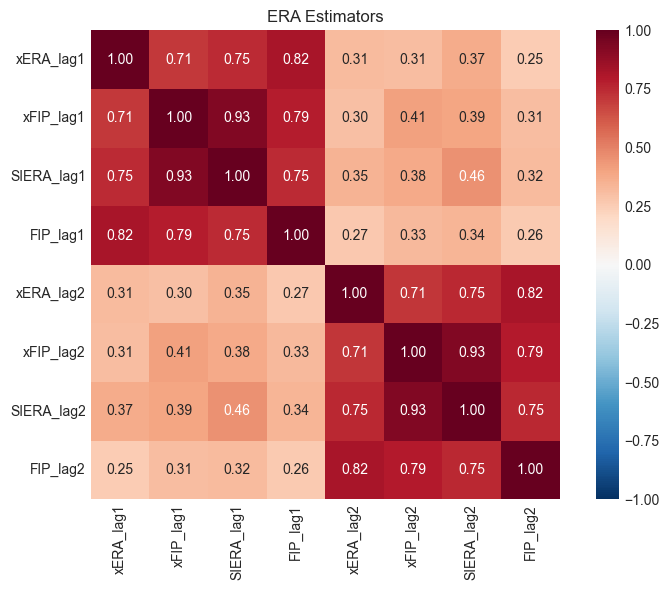

,xERA_lag1,xFIP_lag1,SIERA_lag1,FIP_lag1,xERA_lag2,xFIP_lag2,SIERA_lag2,FIP_lag2
xERA_lag1,1.000000,0.706192,0.745248,0.822212,0.313851,0.306976,0.368406,0.250308
xFIP_lag1,0.706192,1.000000,0.928816,0.786903,0.300463,0.408203,0.392352,0.311546
SIERA_lag1,0.745248,0.928816,1.000000,0.749383,0.349024,0.379889,0.458490,0.317371
FIP_lag1,0.822212,0.786903,0.749383,1.000000,0.269933,0.327452,0.339350,0.263884
xERA_lag2,0.313851,0.300463,0.349024,0.269933,1.000000,0.712698,0.753026,0.822343
xFIP_lag2,0.306976,0.408203,0.379889,0.327452,0.712698,1.000000,0.927176,0.792412
SIERA_lag2,0.368406,0.392352,0.458490,0.339350,0.753026,0.927176,1.000000,0.754803
FIP_lag2,0.250308,0.311546,0.317371,0.263884,0.822343,0.792412,0.754803,1.000000


In [22]:
# Focused analysis: ERA estimators
era_features = ['xERA_lag1', 'xFIP_lag1', 'SIERA_lag1', 'FIP_lag1', 'ERA_lag1',
                'xERA_lag2', 'xFIP_lag2', 'SIERA_lag2', 'FIP_lag2']
plot_group_correlation(pitchers, era_features, 'ERA Estimators')

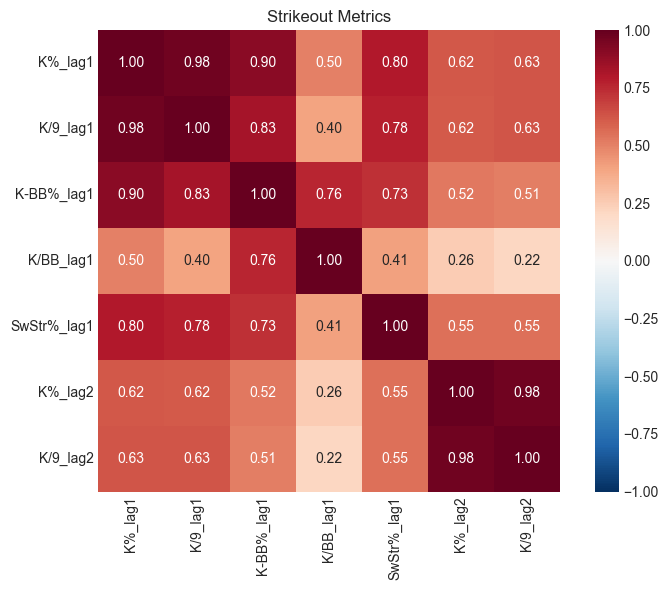

,K%_lag1,K/9_lag1,K-BB%_lag1,K/BB_lag1,SwStr%_lag1,K%_lag2,K/9_lag2
K%_lag1,1.000000,0.976115,0.902026,0.501394,0.800335,0.620988,0.628225
K/9_lag1,0.976115,1.000000,0.830422,0.400918,0.775700,0.615937,0.631157
K-BB%_lag1,0.902026,0.830422,1.000000,0.760235,0.727260,0.524720,0.509237
K/BB_lag1,0.501394,0.400918,0.760235,1.000000,0.412866,0.255686,0.216599
SwStr%_lag1,0.800335,0.775700,0.727260,0.412866,1.000000,0.553598,0.554258
K%_lag2,0.620988,0.615937,0.524720,0.255686,0.553598,1.000000,0.976077
K/9_lag2,0.628225,0.631157,0.509237,0.216599,0.554258,0.976077,1.000000


In [23]:
# Focused analysis: Strikeout metrics
k_features = ['K%_lag1', 'K/9_lag1', 'K-BB%_lag1', 'K/BB_lag1', 'SwStr%_lag1',
              'K%_lag2', 'K/9_lag2']
plot_group_correlation(pitchers, k_features, 'Strikeout Metrics')

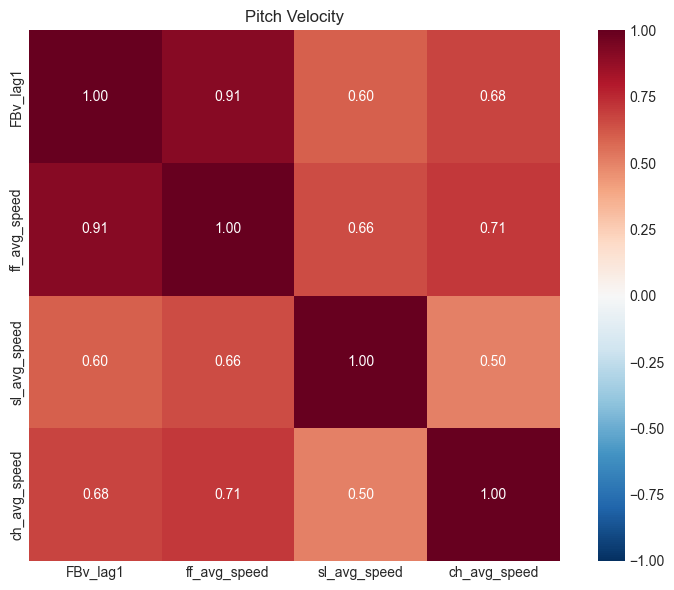

In [24]:
# Focused analysis: Velocity features
velo_features = [c for c in pitcher_features if 'velo' in c.lower() or 'speed' in c.lower() 
                 or c.startswith('v') and ('lag1' in c)]
# Also add FBv
velo_features = ['FBv_lag1', 'ff_avg_speed', 'sl_avg_speed', 'ch_avg_speed']
velo_features = [f for f in velo_features if f in pitchers.columns]
if len(velo_features) >= 2:
    plot_group_correlation(pitchers, velo_features, 'Pitch Velocity')

In [25]:
# Pitcher lag correlations
pitcher_lag_pairs = []
for col in pitchers.columns:
    if '_lag1' in col:
        lag2_col = col.replace('_lag1', '_lag2')
        if lag2_col in pitchers.columns:
            corr = pitchers[col].corr(pitchers[lag2_col])
            pitcher_lag_pairs.append({'Metric': col.replace('_lag1', ''), 'Lag1-Lag2 Corr': corr})

pitcher_lag_df = pd.DataFrame(pitcher_lag_pairs).sort_values('Lag1-Lag2 Corr', ascending=False)
print("Pitcher Lag1 vs Lag2 Correlations:")
print(f"Mean correlation: {pitcher_lag_df['Lag1-Lag2 Corr'].mean():.3f}")
pitcher_lag_df.head(20)

Pitcher Lag1 vs Lag2 Correlations:
Mean correlation: 0.663


,Metric,Lag1-Lag2 Corr
54,Age,0.987787
46,CH-X (pi),0.987660
40,SI-X (pi),0.984148
38,FA-X (pi),0.967916
48,CU-X (pi),0.939271
50,FS-X (pi),0.930440
24,FBv,0.918334
28,CHv,0.902627
44,SL-X (pi),0.890133
30,vFS (pi),0.879889


In [26]:
# Select pitcher representatives
target_col_p = 'Fpoints_IP' if 'Fpoints_IP' in pitchers.columns else 'target'
pitcher_reps = select_representatives(pitchers, pitcher_features, pitcher_clusters, target_col_p)
print("\nRecommended Representative Features (Pitchers):")
pitcher_reps


Recommended Representative Features (Pitchers):


,Cluster,Size,Representative,Target_Corr,All_Features
0,1,1,LD%_lag1,0.039547,LD%_lag1
1,2,1,LD%_lag2,0.004247,LD%_lag2
2,3,1,LD%,0.200904,LD%
3,4,1,SL-Z (pi),0.030354,SL-Z (pi)
4,5,1,SL-Z (pi)_lag1,0.040078,SL-Z (pi)_lag1
...,...,...,...,...,...
77,78,1,H/9_lag1,0.273443,H/9_lag1
78,79,5,K%_lag1,0.461512,"K%_lag1, K-BB%_lag1, K/9_lag1, SIERA_lag1, xFI..."
79,80,3,SwStr%_lag1,0.402458,"SwStr%_lag1, Contact%_lag1, O-Contact%_lag1"
80,81,1,Z-Contact%_lag1,0.372630,Z-Contact%_lag1


---
# Summary & Recommendations
---

In [27]:
print("=" * 80)
print("MULTICOLLINEARITY ANALYSIS SUMMARY")
print("=" * 80)

print("\n" + "-" * 80)
print("BATTERS")
print("-" * 80)
print(f"Total features: {len(batter_features)}")
print(f"Highly correlated pairs (|r| > 0.8): {len(high_corr_df)}")
print(f"Features with VIF > 10: {len(batter_vif[batter_vif['VIF'] > 10])}")
print(f"Number of clusters (threshold=0.3): {batter_clusters['Cluster'].nunique()}")
print(f"Average lag1-lag2 correlation: {lag_corr_df['Lag1-Lag2 Corr'].mean():.3f}")

print("\n" + "-" * 80)
print("PITCHERS")
print("-" * 80)
print(f"Total features: {len(pitcher_features)}")
print(f"Highly correlated pairs (|r| > 0.8): {len(pitcher_high_corr_df)}")
print(f"Features with VIF > 10: {len(pitcher_vif[pitcher_vif['VIF'] > 10])}")
print(f"Number of clusters (threshold=0.3): {pitcher_clusters['Cluster'].nunique()}")
print(f"Average lag1-lag2 correlation: {pitcher_lag_df['Lag1-Lag2 Corr'].mean():.3f}")

print("\n" + "-" * 80)
print("KEY FINDINGS")
print("-" * 80)
print("""
1. LAG REDUNDANCY: Lag1 and Lag2 of same metric are highly correlated (avg r > 0.7).
   → Solution: Use Level + Trend approach (already implemented)

2. EXPECTED STATS: xBA, xSLG, xwOBA are highly correlated (r > 0.85).
   → Solution: Keep only xwOBA (most comprehensive)

3. BATTED BALL QUALITY: EV, HardHit%, Barrel% all measure contact quality (r > 0.7).
   → Solution: Keep only Barrel% (most predictive of outcomes)

4. STRIKEOUT METRICS: K%, K/9, SwStr% highly correlated.
   → Solution: Keep K% (outcome) and optionally SwStr% (skill predictor)

5. ERA ESTIMATORS: xERA, xFIP, SIERA, FIP all estimate true talent (r > 0.8).
   → Solution: Keep only xERA or SIERA

6. PITCH MOVEMENT: 28 movement features are partially redundant.
   → Solution: Keep Stuff+ (composite) or drop movement entirely
""")

MULTICOLLINEARITY ANALYSIS SUMMARY

--------------------------------------------------------------------------------
BATTERS
--------------------------------------------------------------------------------
Total features: 81
Highly correlated pairs (|r| > 0.8): 44
Features with VIF > 10: 59
Number of clusters (threshold=0.3): 38
Average lag1-lag2 correlation: 0.689

--------------------------------------------------------------------------------
PITCHERS
--------------------------------------------------------------------------------
Total features: 185
Highly correlated pairs (|r| > 0.8): 176
Features with VIF > 10: 181
Number of clusters (threshold=0.3): 82
Average lag1-lag2 correlation: 0.663

--------------------------------------------------------------------------------
KEY FINDINGS
--------------------------------------------------------------------------------

1. LAG REDUNDANCY: Lag1 and Lag2 of same metric are highly correlated (avg r > 0.7).
   → Solution: Use Level + Trend 

In [28]:
# Final recommended feature sets
print("\n" + "=" * 80)
print("RECOMMENDED REDUCED FEATURE SETS")
print("=" * 80)

print("\nBATTERS (reduced from ~50 to ~12):")
batter_reduced = [
    'xwOBA_lag1',      # Contact quality (replaces xBA, xSLG)
    'xwOBA_trend',     # Contact trajectory
    'Barrel%_lag1',    # Batted ball quality (replaces EV, HardHit%, Hard%)
    'K%_lag1',         # Strikeout rate
    'BB%_lag1',        # Walk rate
    'O-Contact%_lag1', # Chase discipline
    'FB%_lag1',        # Fly ball tendency
    'HR/FB_lag1',      # Power per fly ball
    'Spd_lag1',        # Speed
    'Age_lag1',        # Age
    'Pull%_lag1',      # Spray tendency
]
for f in batter_reduced:
    print(f"  - {f}")

print("\nPITCHERS (reduced from ~119 to ~15):")
pitcher_reduced = [
    'K%_lag1',         # Strikeout ability
    'K%_trend',        # Strikeout trajectory
    'BB%_lag1',        # Walk prevention
    'SwStr%_lag1',     # Swing and miss (skill)
    'xERA_lag1',       # Run prevention (replaces xFIP, SIERA, FIP)
    'xERA_trend',      # ERA trajectory
    'Barrel%_lag1',    # Contact quality allowed
    'GB%_lag1',        # Ground ball tendency
    'ff_avg_speed',    # Fastball velocity
    'ff_avg_spin',     # Fastball spin
    'Stuff+_lag1',     # Overall stuff quality
    'SP_pct_lag1',     # Role (SP vs RP)
    'Age_lag1',        # Age
]
for f in pitcher_reduced:
    print(f"  - {f}")


RECOMMENDED REDUCED FEATURE SETS

BATTERS (reduced from ~50 to ~12):
  - xwOBA_lag1
  - xwOBA_trend
  - Barrel%_lag1
  - K%_lag1
  - BB%_lag1
  - O-Contact%_lag1
  - FB%_lag1
  - HR/FB_lag1
  - Spd_lag1
  - Age_lag1
  - Pull%_lag1

PITCHERS (reduced from ~119 to ~15):
  - K%_lag1
  - K%_trend
  - BB%_lag1
  - SwStr%_lag1
  - xERA_lag1
  - xERA_trend
  - Barrel%_lag1
  - GB%_lag1
  - ff_avg_speed
  - ff_avg_spin
  - Stuff+_lag1
  - SP_pct_lag1
  - Age_lag1



Verifying reduced feature set correlations...


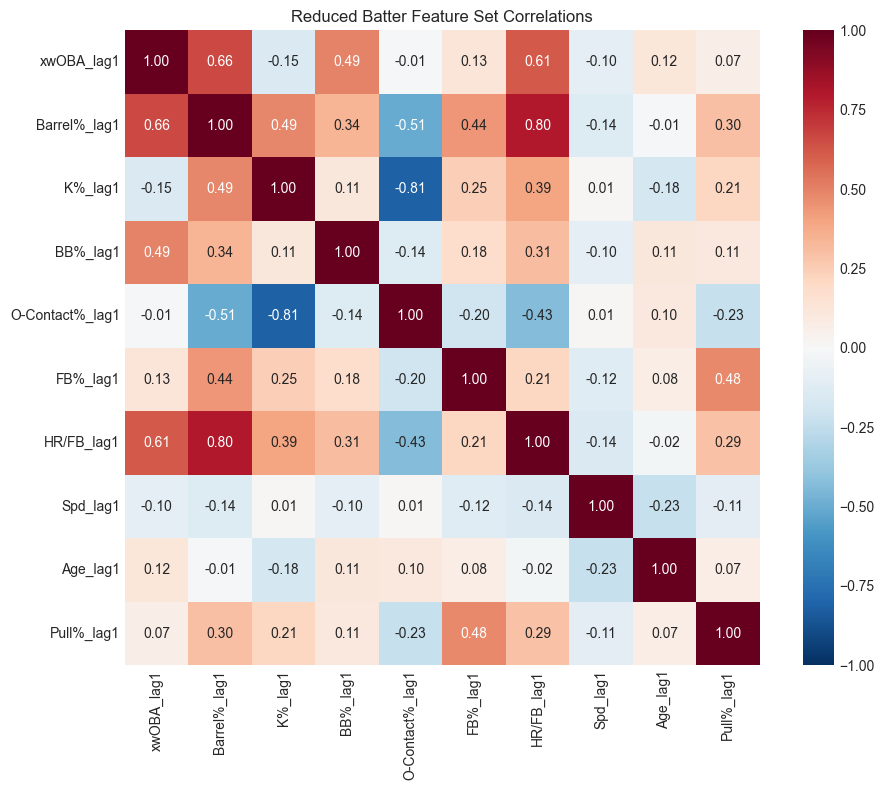


Max correlation in reduced set: 0.814


In [29]:
# Verify reduced set correlations
print("\nVerifying reduced feature set correlations...")

# Check which features exist
batter_reduced_available = [f for f in batter_reduced if f in batters.columns]
if len(batter_reduced_available) >= 2:
    reduced_corr = batters[batter_reduced_available].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(reduced_corr, annot=True, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, fmt='.2f', ax=ax, square=True)
    ax.set_title('Reduced Batter Feature Set Correlations', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Check max off-diagonal correlation
    mask = ~np.eye(reduced_corr.shape[0], dtype=bool)
    max_corr = reduced_corr.where(mask).abs().max().max()
    print(f"\nMax correlation in reduced set: {max_corr:.3f}")
else:
    print("Not enough features available to verify. Run feature engineering first.")